In [24]:
# ! pip install pandas

In [25]:
  #! pip install keras

In [26]:
# ! pip install tensorflow

# Importing Modules

# Data_Analysi_Libraries

In [2]:
import pandas as pd 
import numpy as np 
import os 
import cv2 
from PIL import Image 
#from keras.preprocessing.image import load_img
from tqdm import tqdm

# Visualizations_Libraries

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings ('ignore') 
import tensorflow as tf 
from keras.models import Sequential, Model 
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input 
from tensorflow.keras.utils import plot_model 
from pathlib import Path 
from sklearn.model_selection import train_test_split 
# from tensorflow.keras.initialiers import random_uniform, glorot_uniform, constant, identity 
# from tensorflow.keras.layers import Add, BatchNormalization, GlobalMaxPlooing2D 
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStoping 
# from tensorflow.keras import datasets, layers,model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam


In [4]:
BASE_DIRS = [r'C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace']

In [5]:
image_paths = [] 
age_labels =[] 
gender_paths = [] 

In [6]:
for BASE_DIR in BASE_DIRS: 
    for filename in tqdm(os.listdir (BASE_DIR)): 
        temp = filename.split('_') 
        if temp[0].isdigit(): # Check if the first part of the filename is a number 
            age = int(temp[0]) 
            gender = int(temp[1]) 
            image_path = os.path.join(BASE_DIR, filename) 
            image_paths.append(image_path) 
            age_labels.append(age) 
            gender_paths.append(gender) 


100%|████████████████████████████████████████████████████████████████████████| 23708/23708 [00:00<00:00, 240674.59it/s]


In [7]:
df = pd.DataFrame()
df['image'],df['age'],df['gender'] = image_paths,age_labels,gender_paths
df.head()

,image,age,gender
0,C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...,100,0
1,C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...,100,0
2,C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...,100,1
3,C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...,100,1
4,C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...,100,1


In [8]:
print(f'DataFrame:{df}')
print(f'DataFrame shape: df{df.shape}')
print(f'first few rows of the dataframe:{df.head()}')

DataFrame:                                                   image  age  gender
0      C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...  100       0
1      C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...  100       0
2      C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...  100       1
3      C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...  100       1
4      C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...  100       1
...                                                  ...  ...     ...
23703  C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...    9       1
23704  C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...    9       1
23705  C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...    9       1
23706  C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...    9       1
23707  C:\Users\ABDUL\Desktop\G&A_detect_Proj\UTKFace...    9       1

[23708 rows x 3 columns]
DataFrame shape: df(23708, 3)
first few rows of the dataframe:                                               image  age  gen

In [9]:
gender_dict = {0:'Male',1:'Female'}

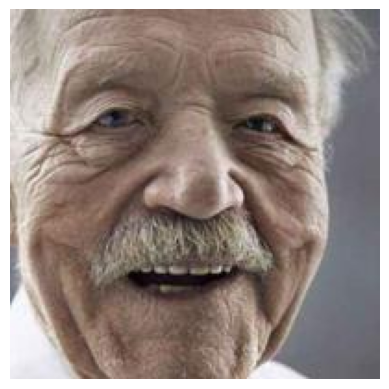

In [10]:
if not df.empty: 
    try: 
        img=Image.open (df ['image'][0]) 
        plt.axis('off') 
        plt.imshow(img) 
        plt.show() 
    except Exception as e: 
        print(f"Error opening image: {e}") 
else: 
    print(f"Dataframe is empty, no images found.")

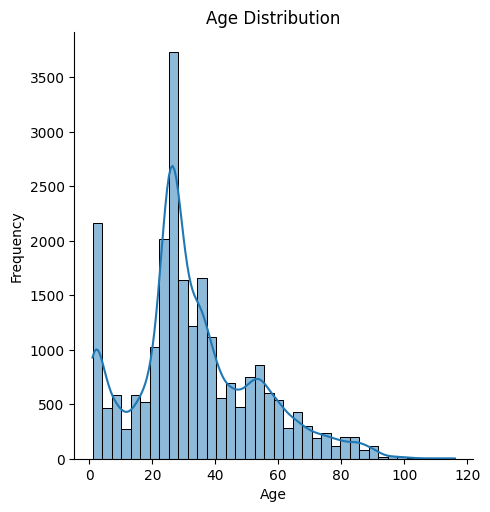

In [11]:
sns.displot(df['age'],kde=True,bins=38)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel("Frequency")
plt.show()

# Feature_Extraction

In [12]:
def extract_feature(images): 
    features = [] 
    for image in tqdm(images): 
        img = Image.open(image).convert("L") 
        img = img.resize((128, 128), Image.BILINEAR) 
        img = np.array(img) 
        features.append(img) 
    features = np.array(features) 
    features = features.reshape(len(features), 128, 128,1) 
    return features
        

In [13]:
x= extract_feature(df['image'])
print(f"X_shape:\t{x.shape}")

100%|████████████████████████████████████████████████████████████████████████████| 23708/23708 [04:49<00:00, 81.91it/s]


X_shape:	(23708, 128, 128, 1)


# Model Creating

In [14]:
x=x/255.0 
y_gender = np.array (df ['gender']) 
y_age = np.array(df['age']) 
print("shape of y_gender:",y_gender.shape) 
print("shape of y_age:", y_age.shape) 


shape of y_gender: (23708,)
shape of y_age: (23708,)


In [15]:
input_shape = (128,128,1) 
inputs = Input (input_shape) 
conv1= Conv2D(32, kernel_size=(3,3), activation ='relu') (inputs) 
maxp1 = MaxPooling2D(pool_size=(2,2)) (conv1) 
conv2 = Conv2D(64, kernel_size=(3,3), activation = 'relu') (maxp1) 
maxp2 = MaxPooling2D(pool_size=(2,2)) (conv2) 
conv3 = Conv2D(128, kernel_size=(3,3), activation = 'relu') (maxp2) 
maxp3 = MaxPooling2D(pool_size=(2,2)) (conv3) 
conv4 = Conv2D(256, kernel_size=(3,3), activation = 'relu') (maxp3) 
maxp4 = MaxPooling2D(pool_size=(2,2)) (conv4) 
flatten = Flatten() (maxp4) 
dense1 = Dense (256, activation='relu') (flatten) 
dense2 = Dense (256, activation='relu') (flatten) 
dropout1 = Dropout (0.3) (dense1) 
dropout2 = Dropout (0.3) (dense2) 
output1=Dense (1, activation='sigmoid', name = 'gender_out') (dropout1) 
output2=Dense (1,activation='relu', name = 'age_out') (dropout2) 
model = Model(inputs=inputs, outputs=[output1, output2]) 
model.summary() 

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 126, 126, 32  320         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 63, 63, 32)   0           ['conv2d[0][0]']                 
                                                                                              